# Interoceptive vs. Perceptual Regions — Whole-Brain Topological Position

**Question.** Do interoceptive/physiological regions occupy a *distinct position in the
global connectome topology* compared with exteroceptive/perceptual sensory regions?

**Why this framing (and not the original one).** The first pass used each region's
*connectivity-with-the-hippocampus* (14-dim) as features. That turned out to be degenerate:
every perceptual region connects to the HPC through exactly **one weak edge** (degree 1),
while interoceptive regions have up to 6. So "distinct HPC-connectivity space" was just a
trivial density difference. We therefore switch to each region's **whole-brain connectional
fingerprint** and ask whether the two groups sit in different neighbourhoods of the global
network — a well-posed, non-degenerate topology question (Passingham et al. 2002 style
connectional fingerprints).

**Method.**
- *Features*: fingerprint = [efferent row (region→all N) ‖ afferent column (all N→region)],
  log-weight-transformed. ~2N dims.
- *Distance*: **cosine** (per-vector scale-invariant, so magnitude/density is factored out —
  we compare the *pattern* of who a region talks to, not how strongly).
- *Test*: **PERMANOVA** (do group centroids differ in location?) + **PERMDISP**
  (or is it just that one group is more dispersed?) + **silhouette** (effect size).
- *Visualisation*: **PCoA** of the exact same cosine distance the test runs on.
- *Confound control*: fingerprints strongly encode the cortex/subcortex divide, and the
  interoceptive set is hypothalamus-heavy while the perceptual set is all cortex. So we also
  run a **cortex-only** contrast (insular interoceptive cortex vs sensory cortex) and colour
  the embedding by major division.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, permdisp
from skbio.stats.ordination import pcoa
import umap
from helpers import log_weight_transform   # br2f kernel has bct, so helpers imports fine

RNG = 42
np.random.seed(RNG)
import os
OUTDIR = '../output/interoceptive_topology'
os.makedirs(OUTDIR, exist_ok=True)

## 1. Load connectome and log-transform

In [2]:
df = pd.read_csv('../data/average_connectome_data.csv', header=0, index_col=0)
# entry[i, j] = weight FROM region i (row/source) -> TO region j (col/target)
L = pd.DataFrame(log_weight_transform(df.values.astype(int)),
                 index=df.index, columns=df.columns)
print('connectome:', L.shape)

div = pd.read_csv('../data/label_major_division_mapping.csv')
div = div[['region_name', 'major_division']].drop_duplicates('region_name')
div = div.set_index('region_name')['major_division']
print('divisions:', div.value_counts().to_dict())

connectome: (392, 392)
divisions: {'CTX': 76, 'HY': 65, 'MY': 51, 'MB': 47, 'TH': 46, 'CNU': 45, 'P': 43, 'CB': 19}


## 2. Define region groups

- **Interoceptive** (scope fixed earlier: insular/visceral cortex + homeostatic hypothalamus).
- **Perceptual** = exteroceptive sensory cortex (visual, auditory, somatosensory). Because we
  no longer require an HPC edge, all 16 are back in (vs only 10 before).

In [3]:
interoceptive = ['AId','AIv','AIp','VISC','GU',
 'PVHam','PVHd','PVHpm','PVHap','PVHpv','PVHmpd','ARH',
 'VMHvl','VMHc','VMHdm','VMHa','DMHa','DMHp','DMHv',
 'RCH','ADP','SBPV','MPO','AVP','TU','VLP','MEPO']
perceptual = ['VISam','VISlla','VISrl','VISlm','VISli','VISal','VISpl','VISll','VISp','VISpm',
 'AUDpo','AUDd','AUDv','AUDp','SSp','SSs']

interoceptive = [r for r in interoceptive if r in L.index]
perceptual    = [r for r in perceptual    if r in L.index]
labeled = interoceptive + perceptual
groups = pd.Series(['interoceptive']*len(interoceptive) + ['perceptual']*len(perceptual),
                   index=labeled)
print(f'interoceptive n={len(interoceptive)}, perceptual n={len(perceptual)}')
print('interoceptive divisions:', div.reindex(interoceptive).value_counts().to_dict())
print('perceptual divisions   :', div.reindex(perceptual).value_counts().to_dict())

interoceptive n=27, perceptual n=16
interoceptive divisions: {'HY': 22, 'CTX': 5}
perceptual divisions   : {'CTX': 16}


## 3. Build whole-brain connectional fingerprints

For every region we concatenate its **outgoing** profile (row of `L`, over all targets) and
its **incoming** profile (column of `L`, over all sources). Self-entries are 0 (diagonal).
Two regions are similar if they send to / receive from a similar set of partners.

In [4]:
efferent = L.copy()                     # row r  = region r -> all targets
afferent = L.T.copy()                   # row r  = all sources -> region r
efferent.columns = ['eff::' + c for c in efferent.columns]
afferent.columns = ['aff::' + c for c in afferent.columns]
FP = pd.concat([efferent, afferent], axis=1)   # (N regions) x (2N features)
print('fingerprint matrix:', FP.shape)

X = FP.loc[labeled].values
print('labeled feature block:', X.shape)

fingerprint matrix: (392, 784)
labeled feature block: (43, 784)


## 4. Cosine distance + PERMANOVA / PERMDISP / silhouette

PERMANOVA asks whether the two groups have different *centroids* (location) in the cosine
space. PERMDISP asks whether they differ only in *spread*. We want PERMANOVA significant and
PERMDISP ideally not — that's the clean "distinct location" reading.

In [5]:
def cosine_dm(mat, ids):
    D = 1.0 - cosine_similarity(mat)
    D = (D + D.T) / 2.0            # enforce symmetry (float)
    np.fill_diagonal(D, 0.0)       # enforce hollow
    D = np.clip(D, 0, None)
    return DistanceMatrix(D, ids=list(ids))

dm = cosine_dm(X, labeled)
grp = groups.reindex(dm.ids).values

pm = permanova(dm, grp, permutations=9999)
pd_ = permdisp(dm, grp, permutations=9999)
sil = silhouette_score(dm.data, grp, metric='precomputed')

print('=== MAIN ANALYSIS (interoceptive n=%d vs perceptual n=%d) ==='
      % ((grp=='interoceptive').sum(), (grp=='perceptual').sum()))
print(f"PERMANOVA  pseudo-F = {pm['test statistic']:.3f}   p = {pm['p-value']:.4f}")
print(f"PERMDISP   F        = {pd_['test statistic']:.3f}   p = {pd_['p-value']:.4f}   "
      f"(low p => groups differ in dispersion, complicating the 'location' story)")
print(f"Silhouette (cosine) = {sil:.3f}   (>0 => groups more internally coherent than mixed)")

/opt/anaconda3/envs/br2f/lib/python3.12/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:214: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.11724608037745346 whereas the largest positive one is 4.1193614608955205.
  warn(


=== MAIN ANALYSIS (interoceptive n=27 vs perceptual n=16) ===
PERMANOVA  pseudo-F = 9.417   p = 0.0001
PERMDISP   F        = 7.193   p = 0.0067   (low p => groups differ in dispersion, complicating the 'location' story)
Silhouette (cosine) = 0.172   (>0 => groups more internally coherent than mixed)


## 5. PCoA visualisation (same distance the test uses)

Coloured by group, then by major division. If the group separation is really just the
cortex/subcortex divide, the division plot will make that obvious.

/opt/anaconda3/envs/br2f/lib/python3.12/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:214: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.11724608037745346 whereas the largest positive one is 4.1193614608955205.
  warn(


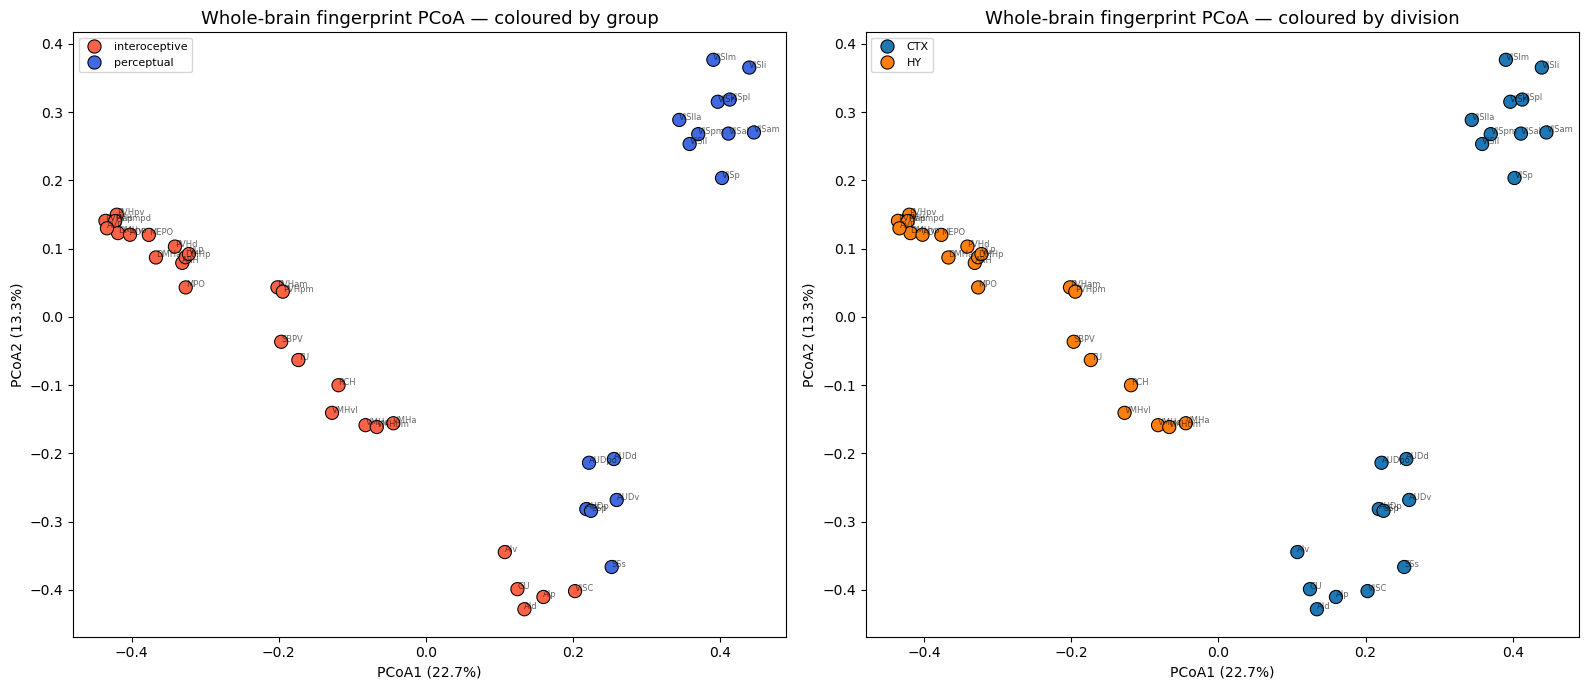

In [6]:
ord_res = pcoa(dm, number_of_dimensions=3)
coords = ord_res.samples[['PC1','PC2']].copy()
coords['group'] = groups.reindex(coords.index).values
coords['division'] = div.reindex(coords.index).values
prop = ord_res.proportion_explained[:2].values * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, key, pal in [(axes[0], 'group', {'interoceptive':'tomato','perceptual':'royalblue'}),
                     (axes[1], 'division', None)]:
    sns.scatterplot(data=coords, x='PC1', y='PC2', hue=key, palette=pal, s=90,
                    edgecolor='k', ax=ax)
    for r, row in coords.iterrows():
        ax.annotate(r, (row['PC1'], row['PC2']), fontsize=6, alpha=0.6)
    ax.set_xlabel(f'PCoA1 ({prop[0]:.1f}%)'); ax.set_ylabel(f'PCoA2 ({prop[1]:.1f}%)')
    ax.set_title(f'Whole-brain fingerprint PCoA — coloured by {key}', fontsize=13)
    ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/pcoa_group_vs_division.png', dpi=150)
plt.show()

## 6. UMAP (nonlinear secondary view)

Small-n UMAP is unstable, so this is a supporting picture, not evidence.

/opt/anaconda3/envs/br2f/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


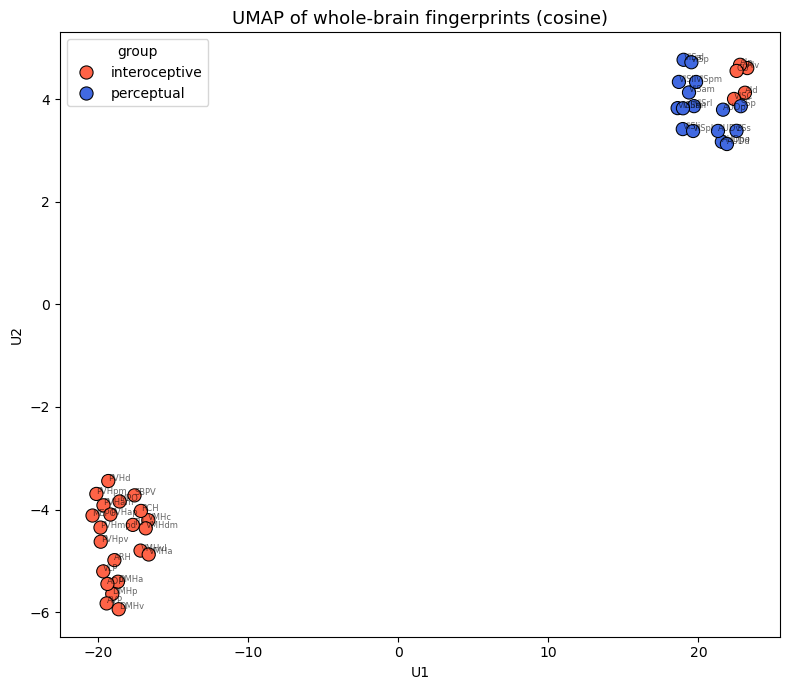

In [7]:
reducer = umap.UMAP(n_neighbors=10, min_dist=0.3, metric='cosine', random_state=RNG)
emb = reducer.fit_transform(X)
ue = pd.DataFrame(emb, columns=['U1','U2'], index=labeled)
ue['group'] = groups.values
plt.figure(figsize=(8, 7))
sns.scatterplot(data=ue, x='U1', y='U2', hue='group',
                palette={'interoceptive':'tomato','perceptual':'royalblue'},
                s=90, edgecolor='k')
for r, row in ue.iterrows():
    plt.annotate(r, (row['U1'], row['U2']), fontsize=6, alpha=0.6)
plt.title('UMAP of whole-brain fingerprints (cosine)', fontsize=13)
plt.tight_layout(); plt.savefig(f'{OUTDIR}/umap_group.png', dpi=150); plt.show()

## 7. Confound control — cortex-only contrast

Restrict to **cortical** regions in both groups (insular interoceptive cortex vs sensory
cortex). This removes the cortex/subcortex divide. If the groups still separate here, the
effect is not merely anatomical class. **Caveat: interoceptive-cortex n is only 5** — low power,
so a null result is weak evidence either way.

In [8]:
ctx = [r for r in labeled if div.get(r) == 'CTX']
ctx_grp = groups.reindex(ctx)
n_i = (ctx_grp=='interoceptive').sum(); n_p = (ctx_grp=='perceptual').sum()
print('cortex-only:', ctx_grp.value_counts().to_dict())
print('interoceptive-CTX:', [r for r in ctx if groups[r]=='interoceptive'])

dm_c = cosine_dm(FP.loc[ctx].values, ctx)
g_c = ctx_grp.reindex(dm_c.ids).values
pm_c = permanova(dm_c, g_c, permutations=9999)
pd_c = permdisp(dm_c, g_c, permutations=9999)
sil_c = silhouette_score(dm_c.data, g_c, metric='precomputed')
print(f"\nPERMANOVA  pseudo-F = {pm_c['test statistic']:.3f}  p = {pm_c['p-value']:.4f}")
print(f"PERMDISP   F        = {pd_c['test statistic']:.3f}  p = {pd_c['p-value']:.4f}")
print(f"Silhouette          = {sil_c:.3f}")

cortex-only: {'perceptual': 16, 'interoceptive': 5}
interoceptive-CTX: ['AId', 'AIv', 'AIp', 'VISC', 'GU']


/opt/anaconda3/envs/br2f/lib/python3.12/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:214: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.07965438662077187 whereas the largest positive one is 2.461036095780116.
  warn(



PERMANOVA  pseudo-F = 5.723  p = 0.0003
PERMDISP   F        = 3.480  p = 0.1637
Silhouette          = 0.216


## 8. Reference: how much does *division* alone separate?

Sanity check on the confound — PERMANOVA using major division as the grouping. If division
explains a large chunk of the fingerprint geometry, the main result must be read in that light.

In [9]:
dm_all_labeled = dm  # reuse main cosine distance over the 43 labeled regions
div_grp = div.reindex(dm.ids).fillna('NA').values
pm_div = permanova(dm, div_grp, permutations=9999)
print(f"PERMANOVA by division (over the 43 labeled regions): "
      f"pseudo-F = {pm_div['test statistic']:.3f}, p = {pm_div['p-value']:.4f}")
print('division counts among labeled:', pd.Series(div_grp).value_counts().to_dict())

PERMANOVA by division (over the 43 labeled regions): pseudo-F = 11.032, p = 0.0001
division counts among labeled: {'HY': 22, 'CTX': 21}


## 9. Summary

Fill in after running:
- Main PERMANOVA (27 vs 16): F, p, silhouette; PERMDISP p.
- Cortex-only (5 vs 16): F, p — the key test of whether the effect survives the anatomical-class control.
- Division PERMANOVA: how strongly anatomy alone structures the space.

Interpretation guide: a distinct interoceptive topological position is best supported when the
main PERMANOVA is significant, PERMDISP is *not* (so it's location not spread), AND the
cortex-only contrast is at least directionally consistent.